In [15]:
using Integrals
using Plots

In [16]:
Hiσ = 0.3
Hcσ = 0.4
H0 = 1.5;

In [17]:
if false
    P(Ha, Hb) = exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / (2*π * Hiσ * Hcσ)
    Haarr = range( 0.0, 3.0, length=100)
    Hbarr = range(-3.0, 0.0, length=100)
    Marr = [P(Ha, Hb) for Ha in Haarr, Hb in Hbarr]
    heatmap(Haarr, Hbarr, Marr, color=:viridis)
end

In [18]:
P(Ha, Hb) = exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / (2 * π * Hiσ * Hcσ)

P (generic function with 1 method)

In [19]:
function Preisach(H, param)
    P(param, H)                 # param = Ha      H = Hb
end

Preisach (generic function with 1 method)

In [20]:
function Intg1D(H1D, param1D)
    domain = (param1D, H1D)             # (-3, Ha)
    params = H1D                    #  -3
    prob = IntegralProblem(Preisach, domain, params)
    sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)
    first(sol)
end

Intg1D (generic function with 1 method)

In [21]:
function Intg2D(Hext, Hlast)
    domain = (Hext, Hlast)      # (-3, 3)
    params = Hext               # -3
    prob = IntegralProblem(Intg1D, domain, params)
    sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)
    first(sol)
end

Intg2D (generic function with 1 method)

In [22]:
Hmax = 3.0
H = -3.0
Intg2D(H, Hmax)

0.9999777619144792

In [23]:
Intg2D(-3.0,2.0)

0.9213440721358417

In [24]:
Npct = 100
Hvals = zeros(2*Npct)
Mvals = zeros(2*Npct)
for (i, Happl) in enumerate(reverse(range(-Hmax, Hmax, length=Npct)))
    Mvals[i] =  1.0 - 2.0 * Intg2D(Happl, Hmax)
    Hvals[i] = Happl
end
for (i, Happl) in enumerate(range(-Hmax, Hmax, length=Npct))
    Mvals[Npct+i] = -1.0 + 2.0 * Intg2D(-Hmax, Happl)
    Hvals[Npct+i] = Happl
end

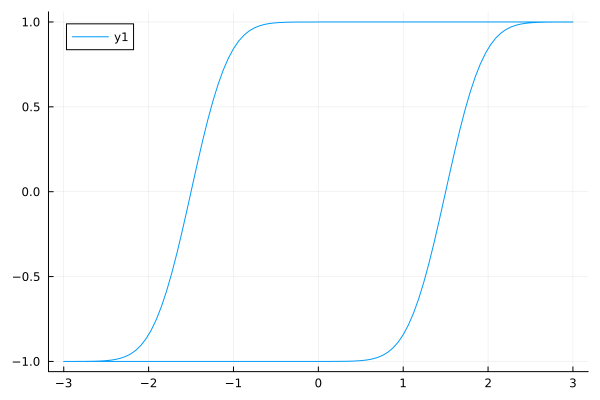

In [25]:
plot(Hvals, Mvals)